In [12]:
using SymPy, DifferentialEquations, LinearAlgebra, Plots, Latexify
# Latexify.set_default(; starred=true)

In [13]:
 # Define symbols
t, Delta, Omega = symbols("t Delta Omega", real=true)

# Define the Hamiltonian
H = Sym[-Delta/2 Omega/2; Omega/2 Delta/2]

# Diagonalize the Hamiltonian
eigenvals, eigenvecs = eigen(H)

normalized_eigenvecs = [eigenvecs[:,i]./ norm(eigenvecs[:,i])  for i in range(1, length(eigenvals))]

# Initial state
psi_0 = Sym[0;1]

# Time evolution operator
U = sum(exp(-im * e * t) * normalized_eigenvecs[i] * normalized_eigenvecs[i]' 
    for (i, e) in enumerate(eigenvals))
psi_t = U * psi_0

psi_t = psi_t ./ norm(psi_t);

In [14]:
latexify(H)

L"\begin{equation}
\left[
\begin{array}{cc}
\frac{ - \Delta}{2} & \frac{\Omega}{2} \\
\frac{\Omega}{2} & \frac{\Delta}{2} \\
\end{array}
\right]
\end{equation}
"

In [15]:
E = [eigenvecs[:,i]./ norm(eigenvecs[:,i])  for i in range(1, length(eigenvals))]
latexify(E[1])

L"\begin{equation}
\left[
\begin{array}{c}
\frac{\frac{ - \Delta}{\Omega} - \frac{\sqrt{\Delta^{2} + \Omega^{2}}}{\Omega}}{\sqrt{\left( \mathrm{Abs}\left( \frac{\Delta}{\Omega} + \frac{\sqrt{\Delta^{2} + \Omega^{2}}}{\Omega} \right) \right)^{2} + 1}} \\
\frac{1}{\sqrt{\left( \mathrm{Abs}\left( \frac{\Delta}{\Omega} + \frac{\sqrt{\Delta^{2} + \Omega^{2}}}{\Omega} \right) \right)^{2} + 1}} \\
\end{array}
\right]
\end{equation}
"

In [20]:
n = Sym[0 0; 0 1]
P_e = simplify(psi_t' * n * psi_t)

println("Probability in excited state:")
latexify(P_e)

Probability in excited state:


"\$\\frac{\\left( \\left( \\left( \\mathrm{Abs}\\left( \\frac{\\Delta - \\sqrt{\\Delta^{2} + \\Omega^{2}}}{\\Omega} \\right) \\right)^{2} + 1 \\right) \\cdot e^{I \\cdot t \\cdot \\sqrt{\\Delta^{2} + \\Omega^{2}}} + \\left( \\mathrm{Abs}\\left( \\frac{\\Delta + \\sqrt{\\Delta^{2} + \\Omega^{2}}}{\\Ome" ⋯ 3324 bytes ⋯ "ga^{2}}} \\cdot \\left( \\left( \\mathrm{Abs}\\left( \\frac{\\Delta - \\sqrt{\\Delta^{2} + \\Omega^{2}}}{\\Omega} \\right) \\right)^{2} + 1 \\right)^{2} \\cdot \\left( \\left( \\mathrm{Abs}\\left( \\frac{\\Delta + \\sqrt{\\Delta^{2} + \\Omega^{2}}}{\\Omega} \\right) \\right)^{2} + 1 \\right)^{2}}\$"

In [21]:
length(eigenvals)

2

In [22]:
f(t_val,Delta_val,Omega_val) = P_e.subs([(t, t_val),(Delta, Delta_val),(Omega, Omega_val)]) |> N

f (generic function with 1 method)

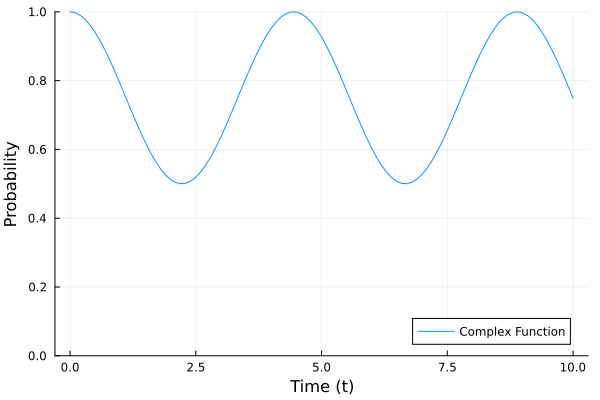

In [23]:
t_vals = 0:0.1:10  # Define time range
Delta_val = 1
Omega_val = 1.0
y_vals = [f(t, Delta_val, Omega_val) for t in t_vals]

plot(t_vals, real(y_vals), ylim=[0,1], label="Complex Function", xlabel="Time (t)", ylabel="Probability")

### RAP

In [24]:
struct parameters
    Omega::Float64
end


In [27]:
Δ0 = 5
δ = 0.1
function (p::parameters)(t)
    global Δ0 = Δ0
    global δ =  δ
    return (p.Ω,Δ0-δ*t)
end

In [32]:
parameters(1.0)

parameters(1.0)

In [28]:
p = parameters(1.0)

t_vals = 0:0.1:10  # Define time range
y_vals = []
for t in t_vals
    Omega_val,Delta_val = p(t)
    push!(y_vals, f(t, Delta_val, Omega_val))
end

plot(t_vals, real(y_vals), ylim=[0,1], label="Complex Function", xlabel="Time (t)", ylabel="Probability")

ErrorException: type parameters has no field Ω